In [3]:
!pip install opencv-python

In [5]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [6]:
dataset = "PetImages"

images = []
labels = []

size = 64

limit = 1000       # 1000 cats + 1000 dogs

In [7]:
cat_folder = os.path.join(dataset, "Cat")

count = 0

for img_name in os.listdir(cat_folder):

    if count == limit:
        break

    path = os.path.join(cat_folder, img_name)

    try:
        img = cv2.imread(path)

        img = cv2.resize(img, (size, size))

        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        images.append(img.flatten())

        labels.append(0)

        count += 1

    except:
        pass

In [10]:
dog_folder = os.path.join(dataset, "Dog")

count = 0

for img_name in os.listdir(dog_folder):

    if count == limit:
        break

    path = os.path.join(dog_folder, img_name)

    try:
        img = cv2.imread(path)

        img = cv2.resize(img, (size, size))

        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        images.append(img.flatten())

        labels.append(1)

        count += 1

    except:
        pass

In [11]:
X = np.array(images)

y = np.array(labels)

print(X.shape)

print(y.shape)

(848, 4096)
(848,)


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [14]:
print(X_train.shape)
print(y_train.shape)

(678, 4096)
(678,)


In [15]:
from sklearn.svm import SVC

svm = SVC(kernel='linear', C=1)

svm.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [16]:
y_pred = svm.predict(X_test)

print(y_pred[:10])

[0 0 0 0 0 0 0 1 0 0]


In [18]:
y_pred = svm.predict(X_test)

In [19]:
print("Accuracy :", accuracy_score(y_test, y_pred))

Accuracy : 0.49411764705882355


In [20]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.54      0.62      0.57        94
           1       0.42      0.34      0.38        76

    accuracy                           0.49       170
   macro avg       0.48      0.48      0.48       170
weighted avg       0.48      0.49      0.49       170



Prediction: Cat


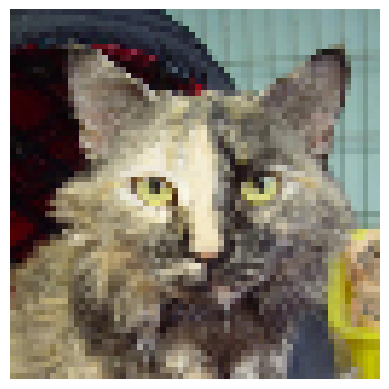

In [21]:
img = cv2.imread("PetImages/Cat/10.jpg")

img = cv2.resize(img, (64,64))

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

prediction = svm.predict([gray.flatten()])

if prediction[0] == 0:
    print("Prediction: Cat")
else:
    print("Prediction: Dog")

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

Prediction: Dog


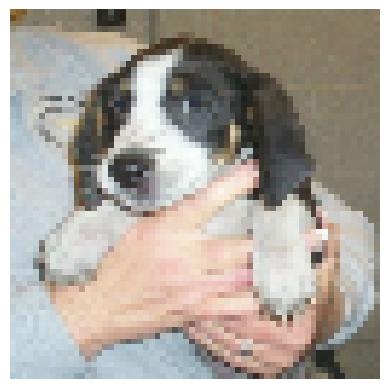

In [22]:
img = cv2.imread("PetImages/Dog/10.jpg")

img = cv2.resize(img, (64,64))

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

prediction = svm.predict([gray.flatten()])

if prediction[0] == 0:
    print("Prediction: Cat")
else:
    print("Prediction: Dog")

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()